## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [2]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [3]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Create session
session = cm.Session(
    name = 'FORMAS',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)

### Styling

In [5]:
from matplotlib.colors import ListedColormap

# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, '110' if '110' in years else '0') for scn, years in session.scenarios('has output').items()]

rename_years = {
    '0' : 'Nuläge',
    '70' : '-30 % CH$_{4}$',
    '100' : '+/-0 % CH$_{4}$',
    '110' : '+10 % CH$_{4}$'
}

rename_scn = lambda x: x.lower().replace('_','-') if x != 'BL' else ''
rename_scn_h = lambda x: ' ' if x != 'BL' else ''

# Sensitivity analysis Scenarios 
sens = []

# Scenario sort
sort = list(
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .xs('100', level='year')
    .sum(axis=1)
    .sort_values()
    .index
)
# Add BL and remove sensitivity analysis scenarios
sort = ['BL'] + [s for s in sort if s not in sens]

def _legend_r(ax):  
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
def _legend_t(ax, ta=1.3):  
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,ta), frameon=False, ncol=2, fontsize=9, reverse=False)
def _legend_n(ax):  
    ax.legend().set_visible(False)

def _annotate(ax, lab):
    ax.annotate(lab, xy=(-0.2, 1.1), xycoords='axes fraction', fontsize=11, fontweight='bold', ha='right', va='bottom')


def _LSU(x):
    '''Gives livestock units (LSU) per head based on a tuple of (species, breed, animal)
    according to https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Glossary:Livestock_unit_(LSU)'''
    sp,br,an = x
    if sp == 'cattle':
        if an == 'cows':
            if br == 'dairy':
                return 1
            else:
                return 0.8
        elif an == 'calves':
            return 0.4
        elif an == 'breeding bulls':
            return 1
        else:
            return 0.8
    elif sp == 'sheep':
        return 0.1
    elif sp == 'pigs':
        if an == 'piglets':
            return 0.027
        elif an == 'sows':
            return 0.5
        else:
            return 0.3
    elif sp == 'horses':
        return 0.8
    elif sp == 'poultry':
        if an == 'broilers':
            return 0.007
        else:
            return 0.014
    else:
        return np.nan

## Get data

In [6]:
sng = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
    .rename({
        'Semi-natural meadows' : 'Slåtteräng',
        'Semi-natural pastures' : 'Naturbetesmark',
        'Semi-natural pastures, thin soils' : 'Alvarbete etc.',
        'Semi-natural pastures, wooded' : 'Skogsbete'
    }, axis=1)
).sum(axis=1)/1_000_000
sng_max = session.get_attr('r','max_land_use','land_use').loc[('MAX_CUR','100'),'semi-natural grasslands'] / 1_000_000
sng_bl = sng.loc['BL'].iloc[0].sum()

In [125]:
cropland = session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None}).loc[:,'cropland']/1_000
cropland_tot = cropland.T.groupby('region').sum().T

ley = cropland.loc[:,'Ley']
ley_prc = ley / cropland_tot * 100

cereals = cropland.loc[:,['Cereals, spring', 'Cereals, winter']].T.groupby('region').sum().T
cereals_prc = cereals / cropland_tot * 100

In [27]:
sort_ani = ['Nötkreatur, mjölkras', 'Nötkreatur, köttras', 'Hästar', 'Hästar (naturvård)', 'Grisar', 'Fåglar', 'Får']

lsu = (
    cm.impact.get_LSU(session, groupby=['species','breed','region'])
    .rename(rename_years)
) / 1_000

lsu.columns = pd.MultiIndex.from_tuples(
    [(f'{sp}, {br}', re) if sp == 'cattle'
     else ('horses', re) if sp == 'horses' and 'cons' not in br
     else ('horses, cons.', re) if sp == 'horses'
     else (sp, re)
     for sp,br,re in lsu.columns],
    names = ['species','region']
)

lsu_reg = (
    lsu
    .T.groupby(['species','region']).sum().T
    .rename({
        'cattle, dairy' : 'Nötkreatur, mjölkras',
        'cattle, beef' : 'Nötkreatur, köttras',
        'sheep' : 'Får',
        'horses' : 'Hästar',
        'horses, cons.' : 'Hästar (naturvård)',
        'poultry' : 'Fåglar',
        'pigs' : 'Grisar'
    }, axis=1)
)
lsu = lsu_reg.T.groupby('species').sum().T
lsu_bl = lsu.loc['BL'].iloc[0].sum()

lsu_reg = lsu_reg.loc[:,sort_ani]
lsu = lsu.loc[:,sort_ani]

In [8]:
# MEAT AND MILK ---------------------------------------------------------------------- ##
meat_milk = (
    session.get_attr('a','prod', ['animal_prod','species'])
    .loc[:,(slice(None),['cattle','sheep'])]
    .rename(rename_years)
    .T.groupby(['animal_prod']).sum().T
)/1_000_000
meat_milk_bl = meat_milk.loc['BL'].iloc[0]

In [9]:
cmp_dict = {
    'CH4bio' : 'CH$_{4}$',
    'CH4fos' : 'CH$_{4}$',
    'CO2' : 'CO$_{2}$',
    'N2O' : 'N$_{2}$O',
    'N2Oind' : 'N$_{2}$O'
}
ghg = (
    cm.impact.get_GHG(session)
    .T.groupby('compound').sum().T
    .rename(index=rename_years, columns=cmp_dict)
    .T.groupby('compound').sum().T
)/1_000_000_000
ghg_bl = ghg.loc['BL'].iloc[0].sum()

## Produce and save figures

In [12]:
lsu

species                               Fåglar        Får      Grisar  \
scn              year                                                 
BL               Nuläge           246.516019  40.142216  297.633696   
MAX_CUR          -30 % CH$_{4}$   246.516019  27.127783  297.633696   
                 +/-0 % CH$_{4}$  246.516019  40.268348  297.633696   
                 +10 % CH$_{4}$   246.516019  44.895669  297.633696   
STEERS           -30 % CH$_{4}$   246.516019  24.836193  297.633696   
                 +/-0 % CH$_{4}$  246.516019  36.879569  297.633696   
                 +10 % CH$_{4}$   246.516019  40.887461  297.633696   
REC_HORSES       -30 % CH$_{4}$   246.516019  27.119898  297.633696   
                 +/-0 % CH$_{4}$  246.516019  40.268535  297.633696   
                 +10 % CH$_{4}$   246.516019  44.876051  297.633696   
WIN_LAMB         -30 % CH$_{4}$   246.516019  33.250648  297.633696   
                 +/-0 % CH$_{4}$  246.516019  49.313248  297.633696   
                 +10 % CH$_{4}$   246.516019  54.518927  297.633696   
CUL_COWS         -30 % CH$_{4}$   246.516019  26.685291  297.633696   
                 +/-0 % CH$_{4}$  246.516019  39.620140  297.633696   
                 +10 % CH$_{4}$   246.516019  44.011956  297.633696   
DRY_COWS         -30 % CH$_{4}$   246.516019  26.434338  297.633696   
                 +/-0 % CH$_{4}$  246.516019  39.260779  297.633696   
                 +10 % CH$_{4}$   246.516019  43.533173  297.633696   
ALL              -30 % CH$_{4}$   246.516019  29.768549  297.633696   
                 +/-0 % CH$_{4}$  246.516019  44.146095  297.633696   
                 +10 % CH$_{4}$   246.516019  49.368636  297.633696   
ALL + NAT_HORSES -30 % CH$_{4}$   246.516019  26.478659  297.633696   
                 +/-0 % CH$_{4}$  246.516019  42.089839  297.633696   
                 +10 % CH$_{4}$   246.516019  46.792081  297.633696   
NAT_HORSES       -30 % CH$_{4}$   246.516019  23.218571  297.633696   
                 +/-0 % CH$_{4}$  246.516019  37.322098  297.633696   
                 +10 % CH$_{4}$   246.516019  42.101352  297.633696   

species                               Hästar  Hästar (naturvård)  \
scn              year                                              
BL               Nuläge           284.400011            0.000000   
MAX_CUR          -30 % CH$_{4}$   284.406804            0.000000   
                 +/-0 % CH$_{4}$  284.390566            0.000000   
                 +10 % CH$_{4}$   284.379436            0.000000   
STEERS           -30 % CH$_{4}$   284.399538            0.000000   
                 +/-0 % CH$_{4}$  284.382309            0.000000   
                 +10 % CH$_{4}$   284.377951            0.000000   
REC_HORSES       -30 % CH$_{4}$   284.428114            0.000000   
                 +/-0 % CH$_{4}$  284.426828            0.000000   
                 +10 % CH$_{4}$   284.426970            0.000000   
WIN_LAMB         -30 % CH$_{4}$   284.406855            0.000000   
                 +/-0 % CH$_{4}$  284.388022            0.000000   
                 +10 % CH$_{4}$   284.384712            0.000000   
CUL_COWS         -30 % CH$_{4}$   284.406272            0.000000   
                 +/-0 % CH$_{4}$  284.389395            0.000000   
                 +10 % CH$_{4}$   284.380103            0.000000   
DRY_COWS         -30 % CH$_{4}$   284.401249            0.000000   
                 +/-0 % CH$_{4}$  284.385418            0.000000   
                 +10 % CH$_{4}$   284.378235            0.000000   
ALL              -30 % CH$_{4}$   284.425070            0.000000   
                 +/-0 % CH$_{4}$  284.413332            0.000000   
                 +10 % CH$_{4}$   284.412418            0.000000   
ALL + NAT_HORSES -30 % CH$_{4}$   284.394088          338.980700   
                 +/-0 % CH$_{4}$  284.385162          161.481799   
                 +10 % CH$_{4}$   284.379119          113.868934   
NAT_HORSES       -30 % CH$_{4}$  

MAX_CUR


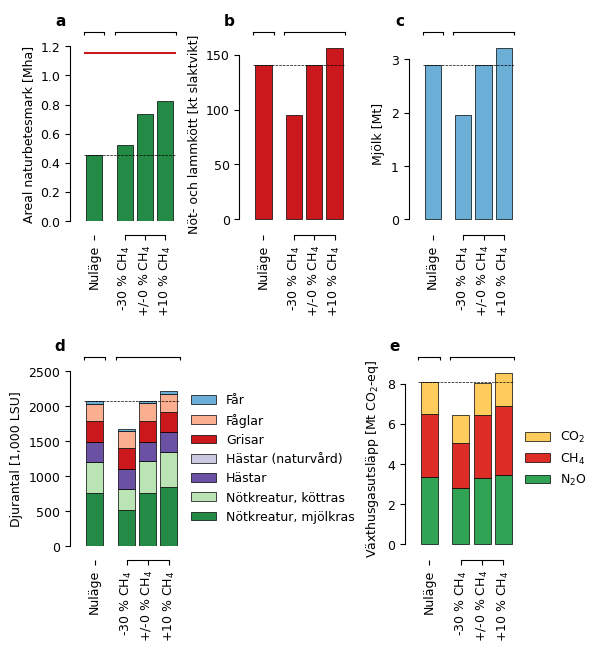

WIN_LAMB


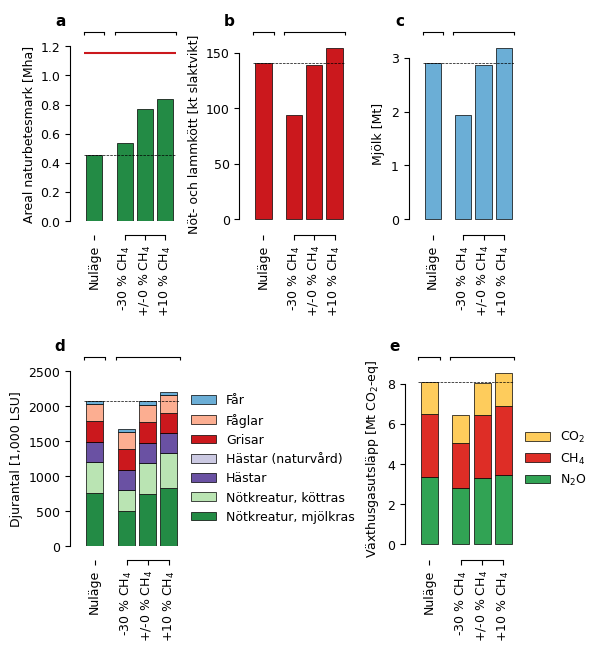

CUL_COWS


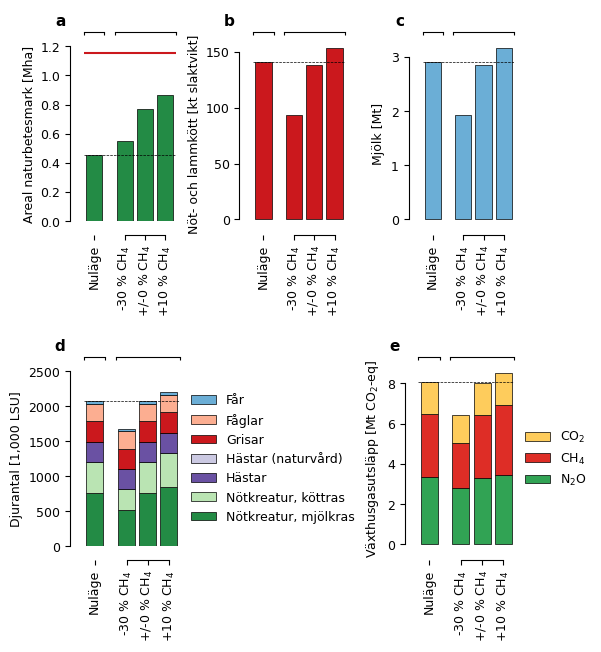

REC_HORSES


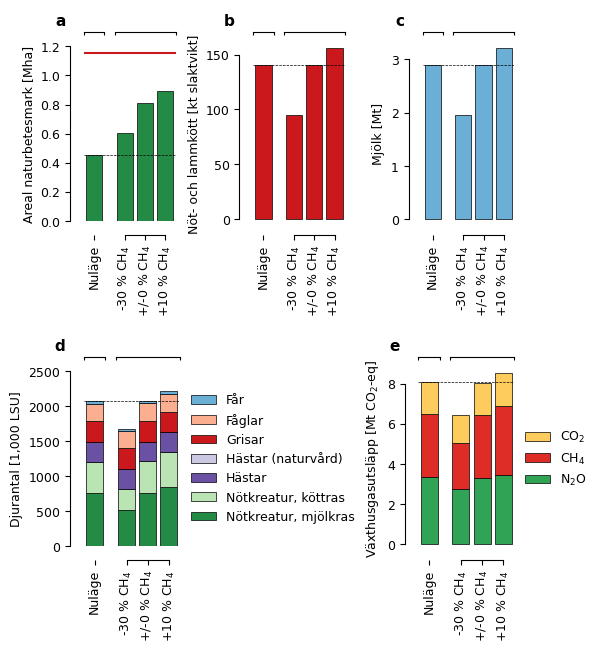

DRY_COWS


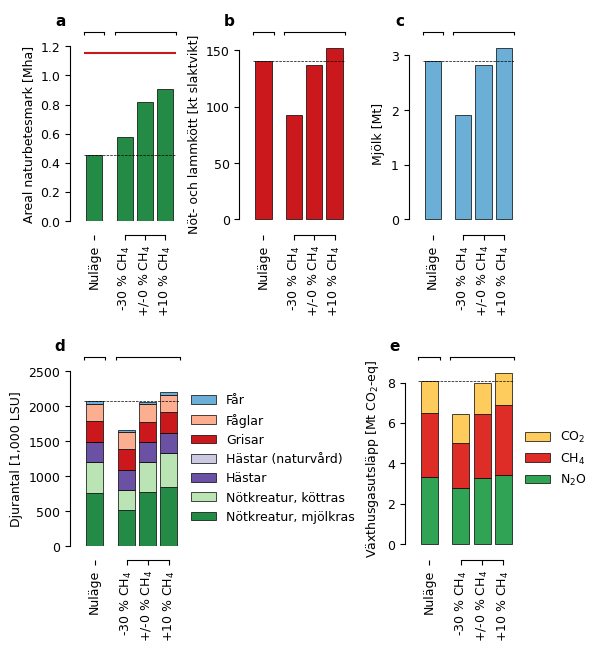

STEERS


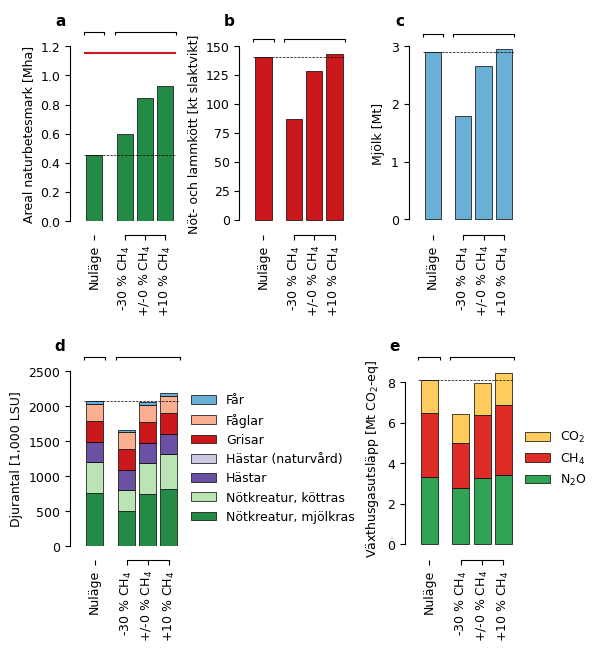

ALL


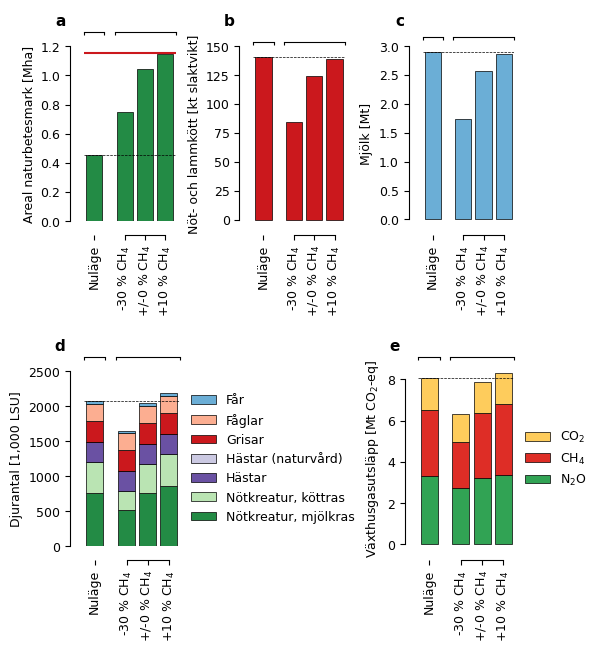

NAT_HORSES


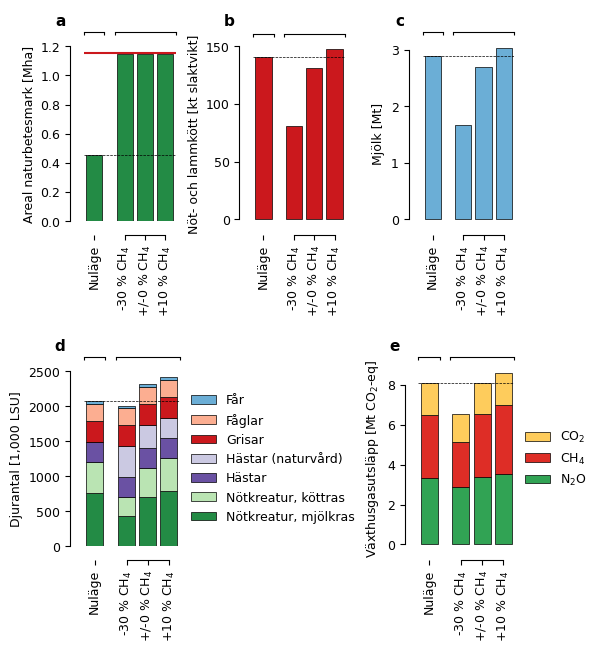

ALL + NAT_HORSES


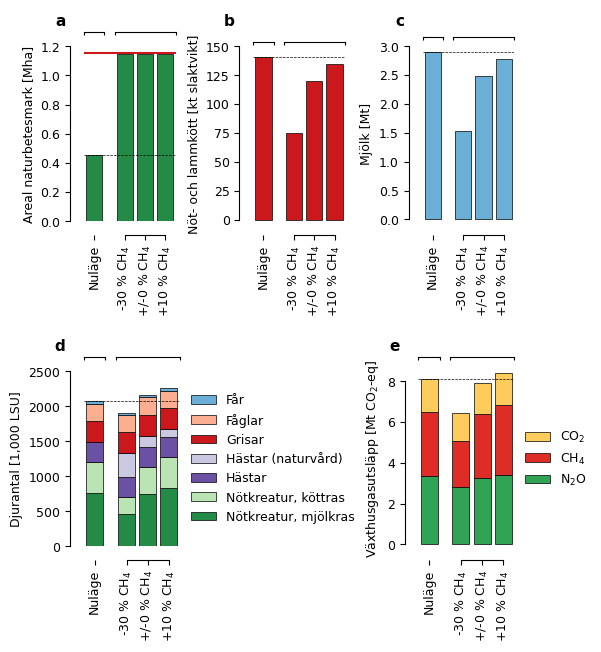

In [29]:
for scn in [s for s in sort if s != 'BL']:
    print(scn)
    fig = plt.figure(figsize = (4.3, 5))
    
    (topfig, bottomfig) = fig.subfigures(2, 1)
    
    top_axs = topfig.subplots(1, 3)
    bottom_axs = bottomfig.subplots(1, 2)
    
    ax = top_axs[0]
    cm.plot.bar(
        sng.loc[['BL']+[scn]].rename(rename_scn_h, level='scn'),
        group_levels='scn',
        ax=ax,
        cmap=ListedColormap(name='X', colors=['#238b45']),
        ylabel='Areal naturbetesmark [Mha]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9,
        ylim = (0,1.2)
    )
    ax.axhline(sng_bl, c='black', linewidth=0.5, linestyle='--')
    ax.axhline(sng_max, c='#cb181d', linewidth=1.5, linestyle='-')
    _legend_n(ax)
    _annotate(ax, 'a')
    
    ax = top_axs[1]
    cm.plot.bar(
        meat_milk.loc[['BL']+[scn],'meat'].rename(rename_scn_h, level='scn'),
        ax=ax,
        sort_categories=True,
        group_levels='scn',
        cmap=ListedColormap(name='X', colors=['#cb181d']),
        ylabel='Nöt- och lammkött [kt slaktvikt]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9
    )
    ax.axhline(meat_milk_bl.loc['meat'], c='black', linewidth=0.5, linestyle='--')
    _legend_n(ax)
    _annotate(ax, 'b')
    
    ax = top_axs[2]
    cm.plot.bar(
        meat_milk.loc[['BL']+[scn],'milk'].rename(rename_scn_h, level='scn')/1000,
        ax=ax,
        sort_categories=True,
        group_levels='scn',
        cmap=ListedColormap(name='X', colors=['#6baed6']),
        ylabel='Mjölk [Mt]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9
    )
    ax.axhline(meat_milk_bl.loc['milk']/1000, c='black', linewidth=0.5, linestyle='--')
    _legend_n(ax)
    _annotate(ax, 'c')
    
    
    ax = bottom_axs[0]
    cm.plot.bar(
        lsu.loc[['BL']+[scn]].rename(rename_scn_h, level='scn'),
        group_levels='scn',
        ax=ax,
        sort_xlabels=False,
        sort_groups=False,
        cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#6a51a3', '#cbc9e2', '#cb181d', '#fcae91', '#6baed6']),
        ylabel='Djurantal [1,000 LSU]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9,
        ylim = (0,2500)
    )
    ax.axhline(lsu_bl, c='black', linewidth=0.5, linestyle='--')
    _legend_r(ax)
    _annotate(ax, 'd')
    
    ax = bottom_axs[1]
    cm.plot.bar(
        ghg.loc[['BL']+[scn]].rename(rename_scn_h, level='scn'),
        ax=ax,
        sort_categories=True,
        group_levels='scn',
        cmap=ListedColormap(name='X', colors=['#31a354','#de2d26', '#fecc5c', '#fcae91', '#9e9ac8', '#6baed6', '#969696']),
        ylabel='Växthusgasutsläpp [Mt CO$_{2}$-eq]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9
    )
    ax.axhline(ghg_bl, c='black', linewidth=0.5, linestyle='--')
    _legend_r(ax)
    _annotate(ax, 'e')
    
    
    # Adjust plots
    topfig.subplots_adjust(left=0, right=1, bottom=0.3, top=1, wspace=0.85, hspace=0)
    bottomfig.subplots_adjust(left=0, right=1, bottom=0, top=0.7, wspace=2.5)
    
    plt.show()

## Maps

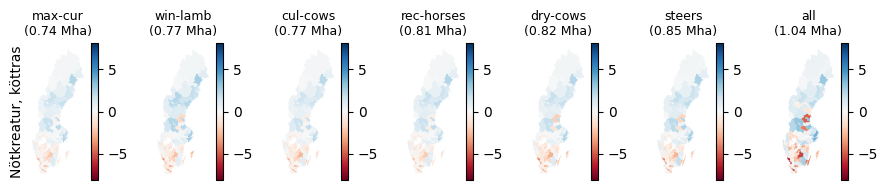

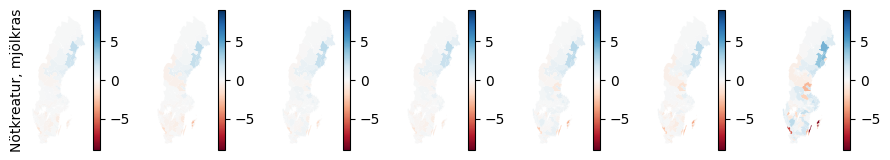

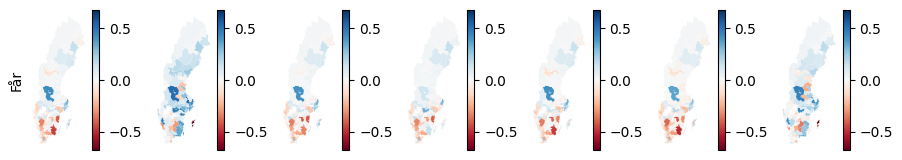

In [40]:
def no_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False, labelleft=False)

sps = ['Nötkreatur, köttras', 'Nötkreatur, mjölkras', 'Får']
scns = [s for s in sort if s not in ['BL','ALL + NAT_HORSES','NAT_HORSES']]

for sp in sps:
    _lsu_reg = lsu_reg.loc[:,sp]
    _lsu_reg = _lsu_reg.sub(_lsu_reg.loc[('BL', 'Nuläge')], axis=1).loc[scns]
    
    n = len(scns)
    
    fig, axs = plt.subplots(1,n, figsize=(1.3*n,2 if sp == sps[0] else 1.7))
    max = _lsu_reg.abs().max().quantile(0.95)
    
    for scn,ax in zip(scns, axs):
        cm.plot.map_from_series(
            _lsu_reg.loc[(scn, '+/-0 % CH$_{4}$')],
            ax = ax,
            cmap = 'RdBu',
            vmax = max,
            vmin = -max
        )
        no_axis(ax)
        if ax == axs[0]:
            ax.set_ylabel(sp)
        if sp == sps[0]:
            ax.set_title(f"{rename_scn(scn)}\n({sng.loc[(scn,'+/-0 % CH$_{4}$')]:.2f} Mha)", size=9)
    
    # fig.suptitle(sp, size=11)
    plt.tight_layout()
    plt.show()

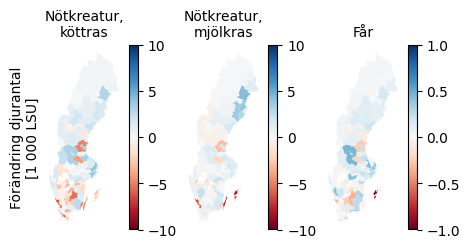

In [167]:
_lsu_reg = (lsu_reg.loc[('ALL', '+/-0 % CH$_{4}$')] - lsu_reg.loc[('BL', 'Nuläge')]) 

n = len(sps)
fig, axs = plt.subplots(1,n, figsize=(1.7*n,2.4))

for sp,ax in zip(sps, axs):
    max = 10 * (0.1 if sp == 'Får' else 1)
    cm.plot.map_from_series(
        _lsu_reg.loc[sp],
        ax = ax,
        cmap = 'RdBu',
        vmin = -max,
        vmax = max
    )
    ax.set_title(sp.replace(', ',',\n'), size=10)
    no_axis(ax)
    if ax == axs[0]:
        ax.set_ylabel('Förändring djurantal\n[1 000 LSU]', size=10)
    

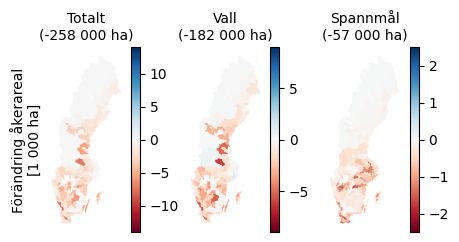

In [169]:
fig, axs = plt.subplots(1,3, figsize=(1.7*3,2.4))

ax = axs[0]
d = cropland_tot.loc[('ALL','100')]-cropland_tot.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-14,
    vmax=14
)
no_axis(ax)
ax.set_ylabel('Förändring åkerareal\n[1 000 ha]', size=10)
ax.set_title(f"Totalt\n({d.sum():.0f} 000 ha)", size=10)

ax = axs[1]
d = ley.loc[('ALL','100')]-ley.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-9,
    vmax=9
)
no_axis(ax)
ax.set_title(f"Vall\n({d.sum():.0f} 000 ha)", size=10)

ax = axs[2]
d = cereals.loc[('ALL','100')]-cereals.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-2.5,
    vmax=2.5
)
no_axis(ax)
ax.set_title(f"Spannmål\n({d.sum():.0f} 000 ha)", size=10)

plt.show()

In [177]:
(cereals.loc[('ALL','100')]-cereals.loc[('BL','0')]).sum() / cereals.loc[('BL','0')].sum() * 100

-6.589556569539458

In [176]:
(ley.loc[('ALL','100')]-ley.loc[('BL','0')]).sum() / ley.loc[('BL','0')].sum() * 100

-17.370152159641133

In [175]:
(cropland_tot.loc[('ALL','100')]-cropland_tot.loc[('BL','0')]).sum() / cropland_tot.loc[('BL','0')].sum() * 100

-10.910730193033325

## Numbers for text

In [30]:
sng_bl = ((sng - sng.loc['BL','Nuläge']) / sng.loc['BL','Nuläge'] * 100).drop('BL')
sng2 = sng.drop('BL').unstack()
sng2_bl = sng_bl.unstack()

sng2 = sng2.sub(sng2.loc['MAX_CUR'], axis=1).div(sng2.loc['MAX_CUR'], axis=1) * 100
sng2_bl = sng2_bl.sub(sng2_bl.loc['MAX_CUR'], axis=1)

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_8800\3849719219.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  sng_bl = ((sng - sng.loc['BL','Nuläge']) / sng.loc['BL','Nuläge'] * 100).drop('BL')
C:\Users\jnka0003\AppData\Local\Temp\ipykernel_8800\3849719219.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  sng2 = sng.drop('BL').unstack()


In [34]:
sng

scn               year           
BL                Nuläge             0.453267
MAX_CUR           -30 % CH$_{4}$     0.523023
                  +/-0 % CH$_{4}$    0.735906
                  +10 % CH$_{4}$     0.827105
STEERS            -30 % CH$_{4}$     0.597237
                  +/-0 % CH$_{4}$    0.845945
                  +10 % CH$_{4}$     0.928504
REC_HORSES        -30 % CH$_{4}$     0.602413
                  +/-0 % CH$_{4}$    0.808990
                  +10 % CH$_{4}$     0.892072
WIN_LAMB          -30 % CH$_{4}$     0.536727
                  +/-0 % CH$_{4}$    0.769248
                  +10 % CH$_{4}$     0.840854
CUL_COWS          -30 % CH$_{4}$     0.551427
                  +/-0 % CH$_{4}$    0.772479
                  +10 % CH$_{4}$     0.866398
DRY_COWS          -30 % CH$_{4}$     0.577285
                  +/-0 % CH$_{4}$    0.818998
                  +10 % CH$_{4}$     0.903784
ALL               -30 % CH$_{4}$     0.748302
                  +/-0 % CH$_{4}$    1.042944


In [31]:
sng_bl

scn               year           
MAX_CUR           -30 % CH$_{4}$      15.389471
                  +/-0 % CH$_{4}$     62.355922
                  +10 % CH$_{4}$      82.476148
STEERS            -30 % CH$_{4}$      31.762550
                  +/-0 % CH$_{4}$     86.632735
                  +10 % CH$_{4}$     104.846772
REC_HORSES        -30 % CH$_{4}$      32.904478
                  +/-0 % CH$_{4}$     78.479614
                  +10 % CH$_{4}$      96.809178
WIN_LAMB          -30 % CH$_{4}$      18.412838
                  +/-0 % CH$_{4}$     69.711813
                  +10 % CH$_{4}$      85.509410
CUL_COWS          -30 % CH$_{4}$      21.655981
                  +/-0 % CH$_{4}$     70.424605
                  +10 % CH$_{4}$      91.145019
DRY_COWS          -30 % CH$_{4}$      27.360732
                  +/-0 % CH$_{4}$     80.687593
                  +10 % CH$_{4}$      99.393030
ALL               -30 % CH$_{4}$      65.090555
                  +/-0 % CH$_{4}$    130.094713
      

In [32]:
sng2

year,-30 % CH$_{4}$,+/-0 % CH$_{4}$,+10 % CH$_{4}$
scn,,,
MAX_CUR,0.000000,0.000000,0.000000
STEERS,14.189405,14.952835,12.259478
REC_HORSES,15.179034,9.931077,7.854742
WIN_LAMB,2.620142,4.530719,1.662278
CUL_COWS,5.430748,4.969750,4.750687
DRY_COWS,10.374657,11.291039,9.270736
ALL,43.072461,41.722403,38.573935
ALL + NAT_HORSES,119.139908,55.746939,38.573935
NAT_HORSES,118.986951,55.638230,38.477213


In [33]:
sng2_bl

year,-30 % CH$_{4}$,+/-0 % CH$_{4}$,+10 % CH$_{4}$
scn,,,
MAX_CUR,0.000000,0.000000,0.000000
STEERS,16.373080,24.276812,22.370624
REC_HORSES,17.515007,16.123691,14.333030
WIN_LAMB,3.023368,7.355891,3.033262
CUL_COWS,6.266511,8.068683,8.668871
DRY_COWS,11.971261,18.331671,16.916882
ALL,49.701085,67.738791,70.388231
ALL + NAT_HORSES,137.474909,90.508457,70.388231
NAT_HORSES,137.298413,90.331961,70.211735
